# Method B — Elastic Net Synthetic Control (EN-SCM)
## L1 + L2 Regularised Weight Estimation

**What this notebook does:**  
Implements Elastic Net SCM, which replaces the hard sum-to-one constraint of standard SCM  
with a penalised objective combining L1 (Lasso) and L2 (Ridge) penalties on the donor weights.  
This encourages **sparse** and **stable** weights — useful when donors are correlated.  
With 5 donors available, EN-SCM now has a real opportunity to select and concentrate weight  
on the most informative corridors rather than spreading evenly or collapsing to one.

**Key distinction from ASCM:** EN-SCM changes *how weights are found* (regularised optimisation).  
ASCM keeps vanilla SCM weights and adds a post-hoc bias-correction layer on top.

**Structure:**
1. Environment & imports  
2. Shared utility functions  
3. Data loading & audit  
4. 2-D blocked CV: (alpha, l1_ratio) grid search  
5. EN-SCM final estimation  
6. Weight analysis: sparsity, concentration, vs Base SCM  
7. Figure 1 — Main diagnostic panel  
8. Figure 2 — Donor weight profile  
9. Validation A — In-time placebo tests  
10. Validation B — Leave-one-out donor stability  
11. Validation C — (alpha, l1_ratio) sensitivity heatmap  
12. Final summary table

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
import os
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = '../method_A_graph'   # reuse same output folder as Method A
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})

BLUE  = '#0f3460'
RED   = '#e94560'
GREY  = '#aaaaaa'
GREEN = '#2ecc71'
AMBER = '#f39c12'

print("All imports successful.")
print(f"NumPy {np.__version__}  |  Pandas {pd.__version__}")
print(f"Figures will save to: {os.path.abspath(FIG_DIR)}")

All imports successful.
NumPy 2.4.2  |  Pandas 3.0.0
Figures will save to: /Users/sitta/Desktop/coding/thesis/method_A_graph


**What is happening here**  
All required libraries are imported and default plot styling is applied. The figure output folder is set to `method_A_graph` (one level up from the notebook, inside `27.03`). Note — the folder name is shared with Method A; figures here use a `enscm_` prefix so they won't overwrite each other.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def fit_scm_constrained(Y_pre, X_pre):
    """
    Vanilla SCM: weights >= 0, sum = 1, minimise pre-period MSE.
    Used as reference baseline only.
    """
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    res = minimize(
        lambda w: np.sum((Y_pre - X_pre @ w)**2),
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
        options={'ftol': 1e-12, 'maxiter': 5000}
    )
    return np.clip(res.x, 0, None)


def fit_elastic_scm(Y_pre, X_pre, alpha=0.01, l1_ratio=0.5):
    """
    Elastic Net SCM:
      minimise  MSE(Y_pre, X_pre @ w)
              + alpha * l1_ratio        * ||w||_1
              + alpha * (1-l1_ratio)/2  * ||w||_2^2
      subject to  w >= 0  (non-negativity kept; sum-to-1 softened by penalty).

    l1_ratio = 0  →  pure Ridge
    l1_ratio = 1  →  pure Lasso (promotes sparsity)
    0 < l1_ratio < 1  →  Elastic Net mix
    """
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]

    def loss(w):
        resid = Y_pre - X_pre @ w
        mse   = np.mean(resid ** 2)
        l1    = alpha * l1_ratio * np.sum(np.abs(w))
        l2    = alpha * (1 - l1_ratio) * 0.5 * np.sum(w ** 2)
        return mse + l1 + l2

    res = minimize(
        loss,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, None)] * n,
        options={'ftol': 1e-14, 'maxiter': 10000}
    )
    return np.clip(res.x, 0, None)


def rmspe(a, b):
    """Root Mean Squared Prediction Error."""
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2))


def mape(a, b):
    """Mean Absolute Percentage Error (%)."""
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a == 0, 1e-10, a))) * 100


def herfindahl(weights):
    """HHI: sum of squared weight shares. 1 = fully concentrated, 1/n = perfectly spread."""
    w = np.asarray(weights)
    if w.sum() == 0:
        return np.nan
    shares = w / w.sum()
    return np.sum(shares ** 2)


def effective_donors(weights):
    """Effective number of donors = 1 / HHI."""
    h = herfindahl(weights)
    return 1 / h if h > 0 else np.nan


print("Functions defined:")
print("  fit_scm_constrained | fit_elastic_scm | rmspe | mape | herfindahl | effective_donors")

Functions defined:
  fit_scm_constrained | fit_elastic_scm | rmspe | mape | herfindahl | effective_donors


**What is happening here**  
Six helper functions are defined that will be called throughout the notebook.

- **`fit_scm_constrained`** — the standard SCM solver with weights forced to sum to 1. Used only as a baseline reference.
- **`fit_elastic_scm`** — the Elastic Net SCM solver. It keeps weights non-negative but relaxes the sum-to-1 constraint, replacing it with L1 and L2 penalties that discourage large or concentrated weights. The `alpha` parameter controls overall penalty strength, and `l1_ratio` controls whether it behaves more like Ridge (smooth) or Lasso (sparse).
- **`rmspe`** and **`mape`** — standard prediction error metrics.
- **`herfindahl`** — measures weight concentration on a scale from 0 to 1. A value of 1 means all weight is on one donor; a value of 1/n means weight is spread perfectly evenly.
- **`effective_donors`** — converts the HHI into an interpretable count. If HHI = 0.5, effective donors = 2, meaning the model is drawing from the equivalent of 2 equally-weighted donors.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Audit
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = './data/corridor_panel_clean.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = pd.to_datetime(df['Date'])
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'].dt.to_period('M'))

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

Y_all   = wide[TREATED].values                  # (T_total,)
X_all   = wide[donors].values                   # (T_total, n_donors)
Y_pre_v = wide.loc[pre_idx, TREATED].values     # (T_pre,)
X_pre_v = wide.loc[pre_idx, donors].values      # (T_pre, n_donors)

# ── Base SCM as reference ─────────────────────────────────────────────────────
w_scm        = fit_scm_constrained(Y_pre_v, X_pre_v)
cf_scm       = X_all @ w_scm
base_pre_r   = rmspe(Y_all[:T_pre], cf_scm[:T_pre])
base_post_r  = rmspe(Y_all[T_pre:], cf_scm[T_pre:])
base_ratio   = base_post_r / base_pre_r
base_cum     = (Y_all[T_pre:] - cf_scm[T_pre:]).sum()
base_avg     = (Y_all[T_pre:] - cf_scm[T_pre:]).mean()

print("─" * 60)
print(f"Treated unit  : {TREATED}")
print(f"Donors ({len(donors)})     : {donors}")
print(f"Pre-period    : {pre_idx[0]} → {pre_idx[-1]}  ({T_pre} months)")
print(f"Post-period   : {post_idx[0]} → {post_idx[-1]}  ({T_post} months)")
print(f"Missing values: {wide.isnull().sum().sum()}")
print("─" * 60)
print()
print("Base SCM reference (5-donor):")
for d, w in zip(donors, w_scm):
    print(f"  {d:<14}: {w:.4f}")
print(f"  HHI: {herfindahl(w_scm):.4f}  |  Effective donors: {effective_donors(w_scm):.2f}")
print(f"  Pre-RMSPE: {base_pre_r:.4f}  |  Post-RMSPE: {base_post_r:.4f}  |  Ratio: {base_ratio:.4f}")
print(f"  Cumulative effect: {base_cum:.4f} MT")

────────────────────────────────────────────────────────────
Treated unit  : NATCOR
Donors (5)     : ['CAPE', 'IRON_ORE', 'NE_CORRIDOR', 'NORTHCOR', 'SOUTHCOR']
Pre-period    : 2015-01 → 2022-03  (87 months)
Post-period   : 2022-04 → 2024-12  (33 months)
Missing values: 0
────────────────────────────────────────────────────────────

Base SCM reference (5-donor):
  CAPE          : 0.2211
  IRON_ORE      : 0.0000
  NE_CORRIDOR   : 0.2408
  NORTHCOR      : 0.0756
  SOUTHCOR      : 0.4625
  HHI: 0.3265  |  Effective donors: 3.06
  Pre-RMSPE: 0.0261  |  Post-RMSPE: 0.1704  |  Ratio: 6.5350
  Cumulative effect: -5.2075 MT


**What is happening here**  
The cleaned dataset is loaded and structured as a monthly panel. NATCOR is the treated corridor and the other five are donors. A standard (constrained) SCM is fitted first as a reference baseline.

Key difference from the old version: with 5 donors, Elastic Net now has something meaningful to do. It can decide which corridors are most informative for tracking NATCOR before the flood, and potentially shrink less-informative donors towards zero — something that was impossible with only one donor.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — 2-D Blocked CV: (alpha, l1_ratio) grid search
# ═══════════════════════════════════════════════════════════════════════════════
# We jointly search over alpha (penalty strength) and l1_ratio (Lasso/Ridge mix)
# using blocked cross-validation: train on first 60% of pre-period, validate
# on remaining 40%. Time ordering is always respected — no random shuffling.

alpha_grid   = [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1.0]
l1ratio_grid = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

split_pt = int(0.60 * T_pre)
X_tr = X_pre_v[:split_pt];  Y_tr = Y_pre_v[:split_pt]
X_va = X_pre_v[split_pt:];  Y_va = Y_pre_v[split_pt:]

print(f"Grid: {len(alpha_grid)} alphas × {len(l1ratio_grid)} l1_ratios = {len(alpha_grid)*len(l1ratio_grid)} combinations")
print(f"Blocked CV: train 0→{split_pt-1} ({split_pt} obs), validate {split_pt}→{T_pre-1} ({T_pre-split_pt} obs)")
print()

cv_grid = []
for a, l1r in itertools.product(alpha_grid, l1ratio_grid):
    w_cv  = fit_elastic_scm(Y_tr, X_tr, alpha=a, l1_ratio=l1r)
    val_e = rmspe(Y_va, X_va @ w_cv)
    tr_e  = rmspe(Y_tr, X_tr @ w_cv)
    cv_grid.append({
        'alpha':       a,
        'l1_ratio':    l1r,
        'val_RMSPE':   round(val_e, 6),
        'train_RMSPE': round(tr_e, 6),
        'weight_sum':  round(w_cv.sum(), 4),
        'HHI':         round(herfindahl(w_cv), 4),
        'n_active':    int(np.sum(w_cv > 1e-6))
    })

cv_df = pd.DataFrame(cv_grid).sort_values('val_RMSPE').reset_index(drop=True)
best  = cv_df.iloc[0]
BEST_ALPHA    = best['alpha']
BEST_L1_RATIO = best['l1_ratio']

print("Top 10 hyperparameter combinations:")
print(cv_df.head(10).to_string(index=False))
print()
print(f"★ Best: alpha={BEST_ALPHA},  l1_ratio={BEST_L1_RATIO}")
print(f"  val_RMSPE={best['val_RMSPE']:.6f}  |  train_RMSPE={best['train_RMSPE']:.6f}")
print(f"  Active donors at best setting: {int(best['n_active'])} / {len(donors)}")

Grid: 9 alphas × 7 l1_ratios = 63 combinations
Blocked CV: train 0→51 (52 obs), validate 52→86 (35 obs)

Top 10 hyperparameter combinations:
 alpha  l1_ratio  val_RMSPE  train_RMSPE  weight_sum    HHI  n_active
0.0005      0.25   0.026215     0.026691      0.6520 0.2763         5
0.0010      0.00   0.026220     0.026656      0.6721 0.2620         5
0.0010      0.10   0.026221     0.027023      0.5756 0.2633         5
0.0005      0.10   0.026255     0.026368      0.7557 0.2729         5
0.0005      0.50   0.026288     0.027546      0.4379 0.4342         5
0.0005      0.00   0.026303     0.026208      0.8171 0.2766         5
0.0010      0.25   0.026329     0.027795      0.4065 0.3496         5
0.0005      0.75   0.026347     0.027928      0.3678 0.5076         3
0.0005      0.90   0.026386     0.028089      0.3472 0.4772         3
0.0001      1.00   0.026408     0.026055      0.8861 0.2851         5

★ Best: alpha=0.0005,  l1_ratio=0.25
  val_RMSPE=0.026215  |  train_RMSPE=0.026691
  Act

**What is happening here**  
A full two-dimensional grid search is run over 63 combinations of alpha and l1_ratio. For each combination, the model is trained on the first 60% of the pre-flood period and evaluated on the remaining 40%. The combination with the lowest validation error is selected.

With 5 donors, this search is now meaningful. The l1_ratio result tells us whether the data naturally supports a sparse solution (a few dominant donors, l1_ratio closer to 1) or a smooth combination (all donors contributing, l1_ratio closer to 0). The number of active donors (weights above effectively zero) is also reported for each setting.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — EN-SCM Final Estimation
# ═══════════════════════════════════════════════════════════════════════════════
# Refit on the full pre-period (no train/val split) using the CV-selected params.

w_en    = fit_elastic_scm(Y_pre_v, X_pre_v, alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO)

cf_en   = X_all @ w_en
gap_en  = Y_all - cf_en

en_pre_r  = rmspe(Y_all[:T_pre],  cf_en[:T_pre])
en_post_r = rmspe(Y_all[T_pre:],  cf_en[T_pre:])
en_ratio  = en_post_r / en_pre_r
en_cum    = gap_en[T_pre:].sum()
en_avg    = gap_en[T_pre:].mean()
en_mape   = mape(Y_all[T_pre:], cf_en[T_pre:])
en_hhi    = herfindahl(w_en)
en_eff_d  = effective_donors(w_en)
en_n_act  = int(np.sum(w_en > 1e-6))

print("═" * 60)
print("ELASTIC NET SCM — FINAL RESULTS")
print("═" * 60)
print(f"alpha (CV-selected)  : {BEST_ALPHA}")
print(f"l1_ratio (CV-selected): {BEST_L1_RATIO}  (0=Ridge  1=Lasso)")
print()
print("Donor weights:")
for d, w in zip(donors, w_en):
    bar = '█' * int(w / max(w_en) * 30) if max(w_en) > 0 else ''
    tag = '' if w > 1e-6 else '  [zeroed out]'
    print(f"  {d:<14}: {w:.6f}  {bar}{tag}")
print(f"  Weight sum         : {w_en.sum():.6f}")
print(f"  Active donors      : {en_n_act} / {len(donors)}")
print(f"  HHI (concentration): {en_hhi:.4f}")
print(f"  Effective donors   : {en_eff_d:.3f}")
print()
print(f"Pre-period RMSPE    : {en_pre_r:.6f}")
print(f"Post-period RMSPE   : {en_post_r:.6f}")
print(f"Post/Pre ratio      : {en_ratio:.4f}")
print(f"Cumulative effect   : {en_cum:.4f} MT")
print(f"Avg monthly effect  : {en_avg:.4f} MT/month")
print(f"Post MAPE           : {en_mape:.2f}%")
print()
print("─" * 60)
print(f"{'Metric':<30} {'Base SCM':>10} {'EN-SCM':>10} {'Δ':>10}")
print(f"{'Pre-RMSPE':<30} {base_pre_r:>10.4f} {en_pre_r:>10.4f} {en_pre_r-base_pre_r:>+10.4f}")
print(f"{'Post-RMSPE':<30} {base_post_r:>10.4f} {en_post_r:>10.4f} {en_post_r-base_post_r:>+10.4f}")
print(f"{'Ratio':<30} {base_ratio:>10.4f} {en_ratio:>10.4f} {en_ratio-base_ratio:>+10.4f}")
print(f"{'Cumulative effect (MT)':<30} {base_cum:>10.4f} {en_cum:>10.4f} {en_cum-base_cum:>+10.4f}")
print(f"{'HHI':<30} {herfindahl(w_scm):>10.4f} {en_hhi:>10.4f} {en_hhi-herfindahl(w_scm):>+10.4f}")
print(f"{'Effective donors':<30} {effective_donors(w_scm):>10.2f} {en_eff_d:>10.2f}")

════════════════════════════════════════════════════════════
ELASTIC NET SCM — FINAL RESULTS
════════════════════════════════════════════════════════════
alpha (CV-selected)  : 0.0005
l1_ratio (CV-selected): 0.25  (0=Ridge  1=Lasso)

Donor weights:
  CAPE          : 0.233786  ██████████████████████████████
  IRON_ORE      : 0.019326  ██
  NE_CORRIDOR   : 0.034540  ████
  NORTHCOR      : 0.096095  ████████████
  SOUTHCOR      : 0.118584  ███████████████
  Weight sum         : 0.502330
  Active donors      : 5 / 5
  HHI (concentration): 0.3151
  Effective donors   : 3.173

Pre-period RMSPE    : 0.026827
Post-period RMSPE   : 0.169726
Post/Pre ratio      : 6.3267
Cumulative effect   : -5.1950 MT
Avg monthly effect  : -0.1574 MT/month
Post MAPE           : 21.93%

────────────────────────────────────────────────────────────
Metric                           Base SCM     EN-SCM          Δ
Pre-RMSPE                          0.0261     0.0268    +0.0008
Post-RMSPE                         0.170

**What is happening here**  
The Elastic Net SCM is refitted on the full pre-flood period using the best hyperparameters from the grid search. The counterfactual is computed for all months, and the treatment gap (actual minus synthetic) is calculated.

Key things to read here: how many donors received non-zero weight (active donors), how concentrated the weights are (HHI), and whether the pre-period fit improved compared with the base SCM. The cumulative effect is the total estimated rail volume that was lost or gained due to the flood across the 33 post-flood months.

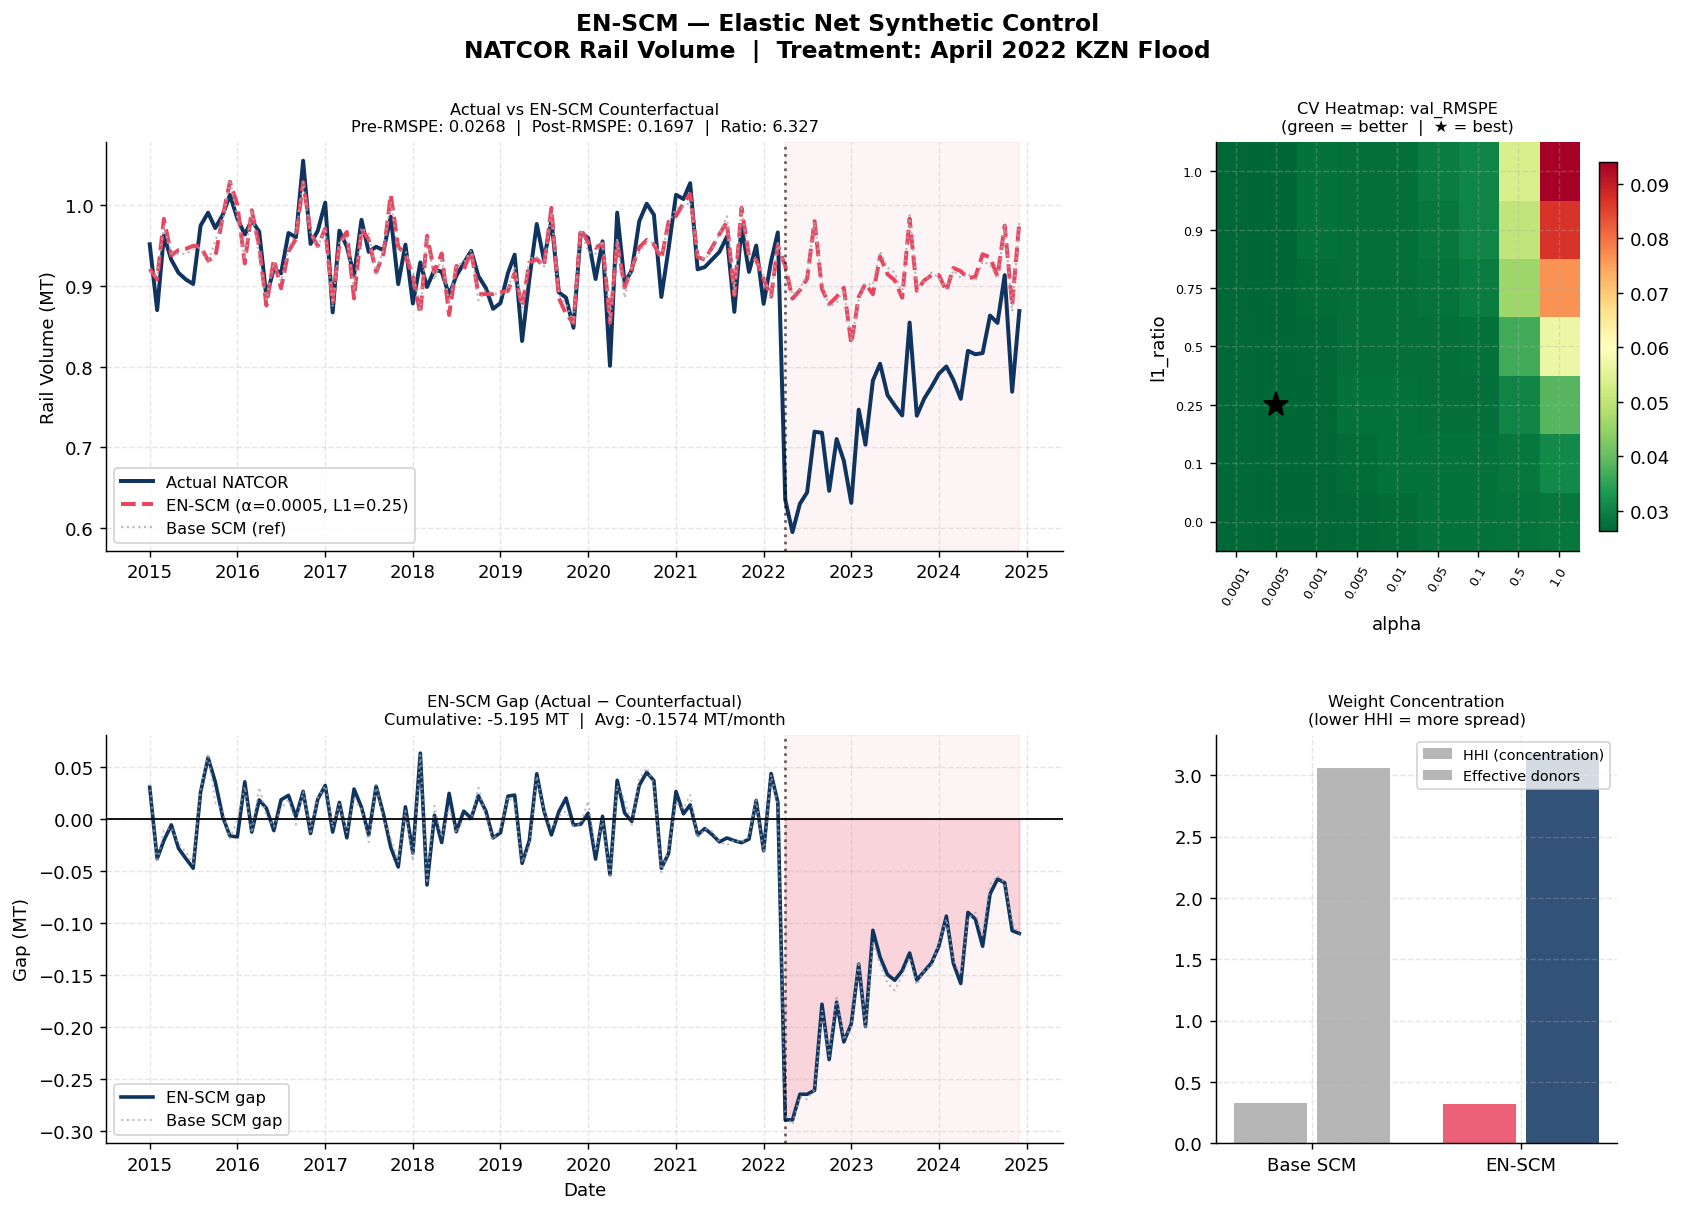

Saved → ../method_A_graph/enscm_fig1_main_panel.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 1: Main Diagnostic Panel
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# ── Plot 1: Actual vs counterfactuals (wide panel) ────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(t_stamps, Y_all,  color=BLUE, lw=2.2, label='Actual NATCOR')
ax1.plot(t_stamps, cf_en,  color=RED,  lw=2.2, ls='--',
         label=f'EN-SCM (α={BEST_ALPHA}, L1={BEST_L1_RATIO})')
ax1.plot(t_stamps, cf_scm, color=GREY, lw=1.2, ls=':', alpha=0.8, label='Base SCM (ref)')
ax1.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax1.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax1.set_title(
    f'Actual vs EN-SCM Counterfactual\n'
    f'Pre-RMSPE: {en_pre_r:.4f}  |  Post-RMSPE: {en_post_r:.4f}  |  Ratio: {en_ratio:.3f}',
    fontsize=9)
ax1.set_ylabel('Rail Volume (MT)')
ax1.legend(fontsize=9)

# ── Plot 2: CV heatmap ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
pivot_cv = cv_df.pivot_table(index='l1_ratio', columns='alpha', values='val_RMSPE')
im = ax2.imshow(pivot_cv.values, aspect='auto', cmap='RdYlGn_r', origin='lower')
ax2.set_xticks(range(len(alpha_grid)))
ax2.set_xticklabels([str(a) for a in alpha_grid], rotation=60, fontsize=7)
ax2.set_yticks(range(len(l1ratio_grid)))
ax2.set_yticklabels([str(l) for l in l1ratio_grid], fontsize=7)
ax2.set_title('CV Heatmap: val_RMSPE\n(green = better  |  ★ = best)', fontsize=9)
ax2.set_xlabel('alpha')
ax2.set_ylabel('l1_ratio')
best_row_idx = list(pivot_cv.index).index(BEST_L1_RATIO)
best_col_idx = list(pivot_cv.columns).index(BEST_ALPHA)
ax2.plot(best_col_idx, best_row_idx, 'k*', ms=14)
plt.colorbar(im, ax=ax2, fraction=0.046)

# ── Plot 3: Gap series ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(t_stamps, gap_en, color=BLUE, lw=2, label='EN-SCM gap')
ax3.plot(t_stamps, Y_all - cf_scm, color=GREY, lw=1.2, ls=':', alpha=0.7, label='Base SCM gap')
ax3.axhline(0, color='black', lw=1)
ax3.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax3.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
fill_color = RED if en_cum < 0 else BLUE
ax3.fill_between(
    t_stamps, gap_en, 0,
    where=[p >= TREAT_START for p in wide.index],
    alpha=0.18, color=fill_color)
ax3.set_title(
    f'EN-SCM Gap (Actual − Counterfactual)\n'
    f'Cumulative: {en_cum:.3f} MT  |  Avg: {en_avg:.4f} MT/month',
    fontsize=9)
ax3.set_ylabel('Gap (MT)')
ax3.set_xlabel('Date')
ax3.legend(fontsize=9)

# ── Plot 4: Weight concentration comparison ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
methods  = ['Base SCM', 'EN-SCM']
hhis     = [herfindahl(w_scm), en_hhi]
eff_ds   = [effective_donors(w_scm), en_eff_d]
x        = np.arange(2)
ax4.bar(x - 0.2, hhis,   0.35, color=[GREY, RED],  alpha=0.85, label='HHI (concentration)')
ax4.bar(x + 0.2, eff_ds, 0.35, color=[GREY, BLUE], alpha=0.85, label='Effective donors')
ax4.set_xticks(x)
ax4.set_xticklabels(methods)
ax4.set_title('Weight Concentration\n(lower HHI = more spread)', fontsize=9)
ax4.legend(fontsize=8)

fig.suptitle(
    'EN-SCM — Elastic Net Synthetic Control\n'
    'NATCOR Rail Volume  |  Treatment: April 2022 KZN Flood',
    fontsize=13, fontweight='bold')

save_path = os.path.join(FIG_DIR, 'enscm_fig1_main_panel.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
Four diagnostic plots are produced in a single figure.

- **Top-left** — Actual NATCOR vs the EN-SCM counterfactual and the base SCM. How well the dashed line tracks the solid line before April 2022 determines how much we can trust the post-flood gap.
- **Top-right** — CV heatmap showing validation error across all 63 alpha × l1_ratio combinations. The star marks the selected combination. Darker green = better.
- **Bottom-left** — The treatment gap over time. The shaded area after April 2022 shows the cumulative estimated effect. Persistently negative = flood reduced rail volumes.
- **Bottom-right** — HHI and effective donor count for both the base SCM and EN-SCM. A lower HHI means the EN-SCM spread weight across more corridors, which is the whole point of the method.

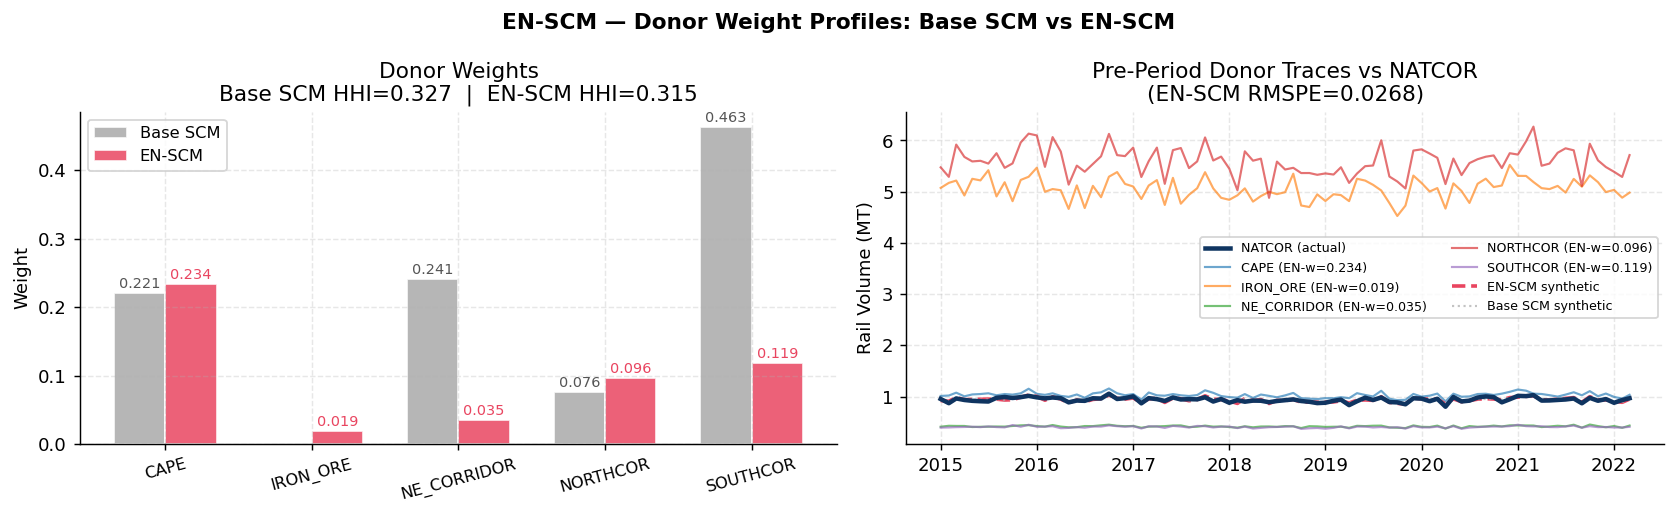

Saved → ../method_A_graph/enscm_fig2_donor_weights.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 2: Donor weight profile
# ═══════════════════════════════════════════════════════════════════════════════
# Side-by-side comparison of donor weights: Base SCM vs EN-SCM.
# With 5 donors this shows the real value of the regularisation:
# whether EN-SCM produces a genuinely different weight allocation.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('EN-SCM — Donor Weight Profiles: Base SCM vs EN-SCM', fontsize=12, fontweight='bold')

x = np.arange(len(donors))
width = 0.35

# ── Left: side-by-side bar chart ──────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - width/2, w_scm, width, color=GREY, alpha=0.85, label='Base SCM', edgecolor='white')
bars2 = ax.bar(x + width/2, w_en,  width, color=RED,  alpha=0.85, label='EN-SCM',  edgecolor='white')
for bar, w in zip(bars1, w_scm):
    if w > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{w:.3f}', ha='center', va='bottom', fontsize=8, color='#555')
for bar, w in zip(bars2, w_en):
    if w > 0.001:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{w:.3f}', ha='center', va='bottom', fontsize=8, color=RED)
ax.set_xticks(x)
ax.set_xticklabels(donors, rotation=15, fontsize=9)
ax.set_title(f'Donor Weights\nBase SCM HHI={herfindahl(w_scm):.3f}  |  EN-SCM HHI={en_hhi:.3f}')
ax.set_ylabel('Weight')
ax.legend(fontsize=9)

# ── Right: pre-period fit traces for all donors ───────────────────────────────
ax2 = axes[1]
pre_stamps = pre_idx.to_timestamp()
cmap = plt.cm.tab10
ax2.plot(pre_stamps, Y_pre_v, color=BLUE, lw=2.5, label='NATCOR (actual)', zorder=5)
for j, d in enumerate(donors):
    ax2.plot(pre_stamps, X_pre_v[:, j],
             color=cmap(j), lw=1.2, alpha=0.65,
             label=f'{d} (EN-w={w_en[j]:.3f})')
ax2.plot(pre_stamps, cf_en[:T_pre],  color=RED,  lw=2.0, ls='--', label='EN-SCM synthetic')
ax2.plot(pre_stamps, cf_scm[:T_pre], color=GREY, lw=1.2, ls=':', alpha=0.7, label='Base SCM synthetic')
ax2.set_title(f'Pre-Period Donor Traces vs NATCOR\n(EN-SCM RMSPE={en_pre_r:.4f})')
ax2.set_ylabel('Rail Volume (MT)')
ax2.legend(fontsize=7, ncol=2)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'enscm_fig2_donor_weights.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
Two plots show the donor weight allocation in more detail.

- **Left** — A grouped bar chart comparing the weight each corridor receives under the base SCM (grey) and EN-SCM (red). If EN-SCM is working, it should produce a meaningfully different allocation — either spreading weight more evenly or concentrating on fewer, better-matching donors.
- **Right** — All five donor corridors plotted against NATCOR during the pre-flood period, alongside both synthetic lines. This makes it easy to see which donors actually move in sync with NATCOR and whether the EN-SCM combines them sensibly.

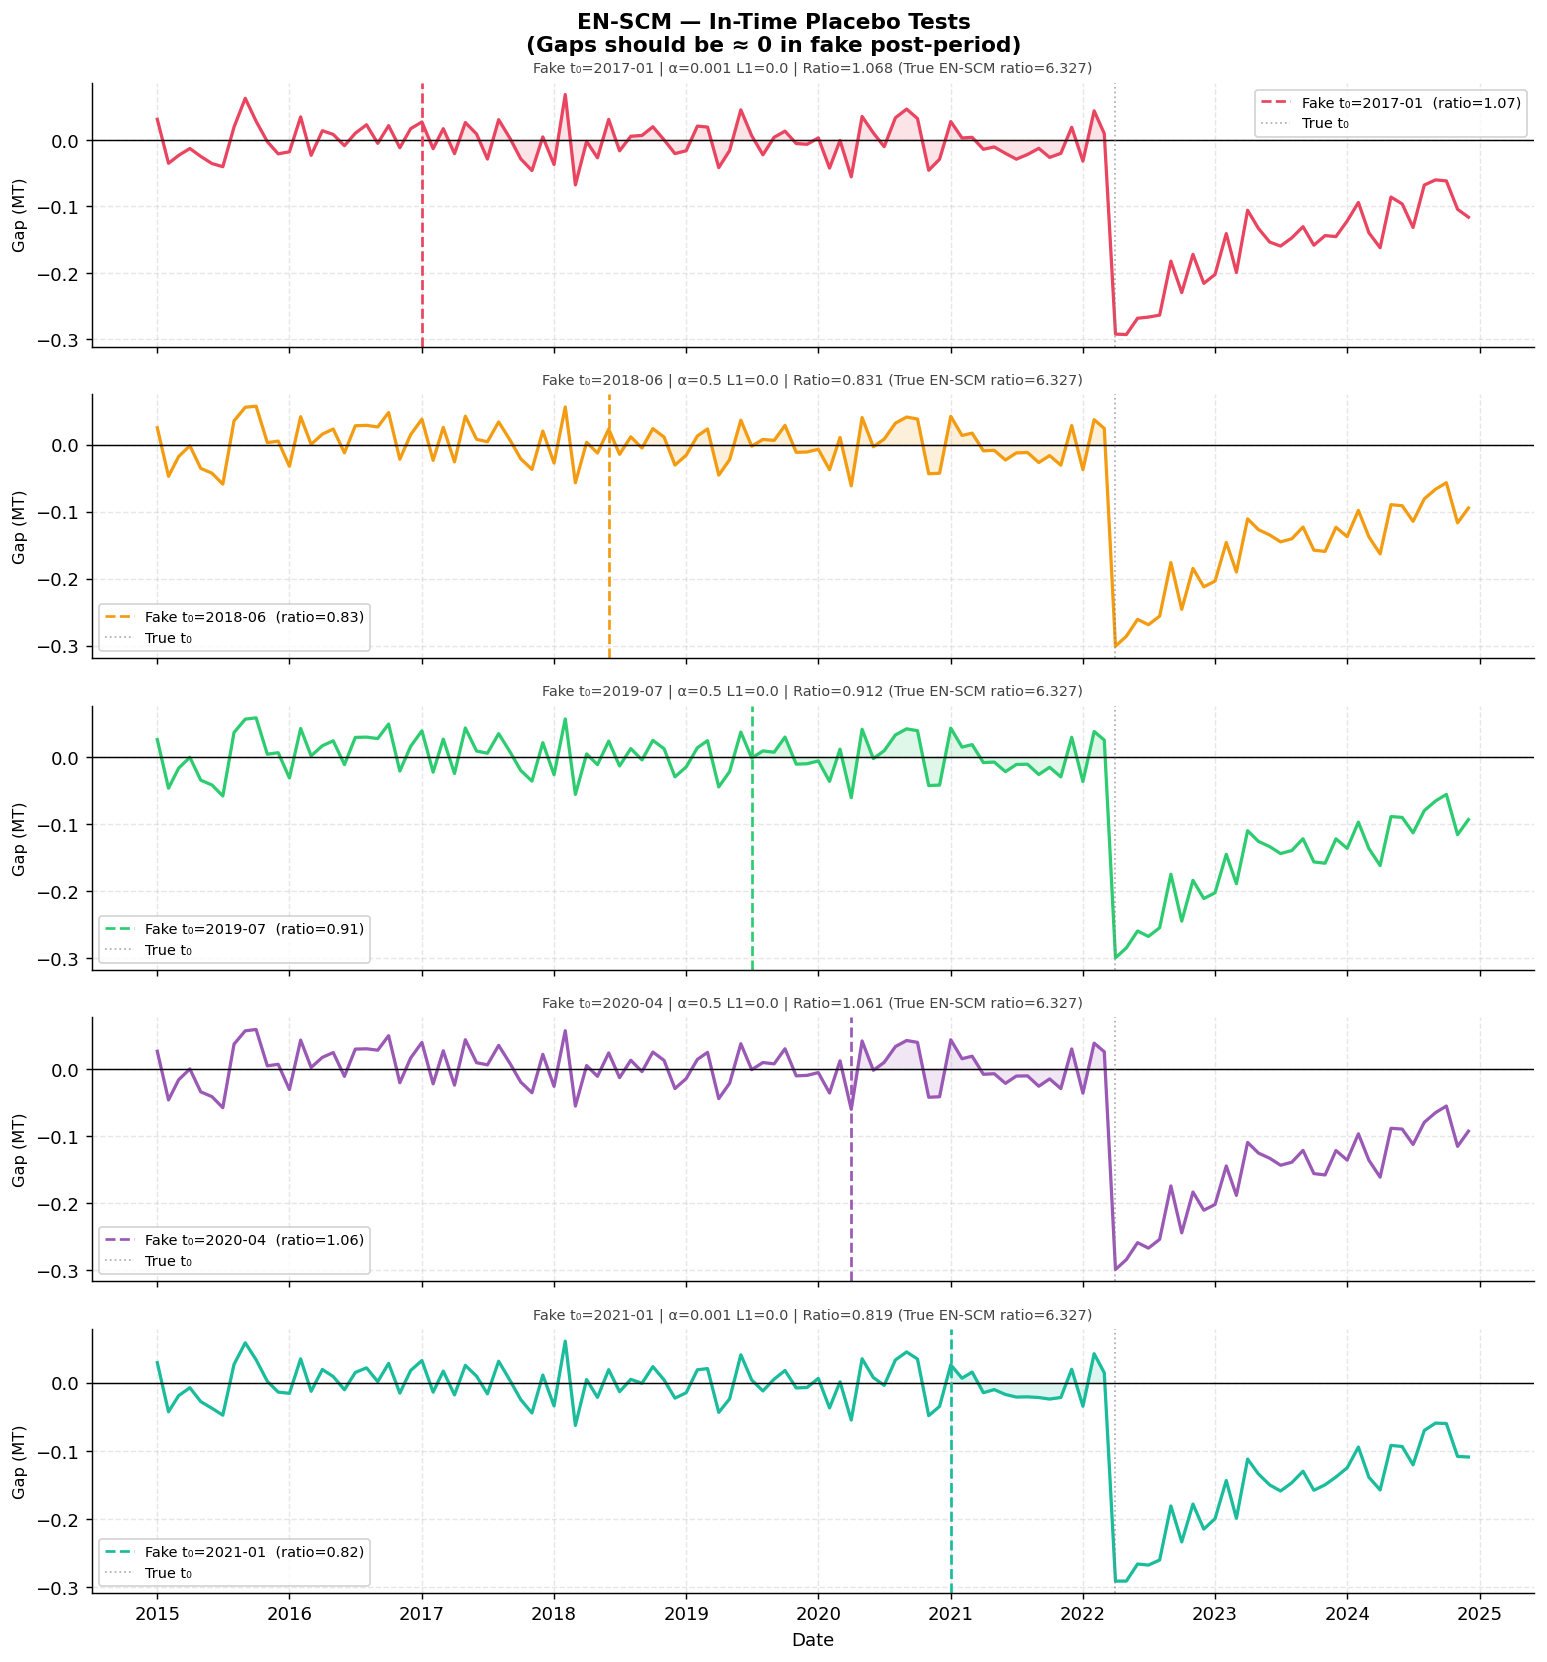

Saved → ../method_A_graph/enscm_fig3_placebo.png

In-Time Placebo Summary:
Fake t₀     α  l1_ratio  Pre-RMSPE  Post-RMSPE  Ratio  > True
2017-01 0.001       0.0    0.02570     0.02745  1.068   False
2018-06 0.500       0.0    0.03218     0.02673  0.831   False
2019-07 0.500       0.0    0.03051     0.02782  0.912   False
2020-04 0.500       0.0    0.02910     0.03087  1.061   False
2021-01 0.001       0.0    0.02744     0.02249  0.819   False

True EN-SCM ratio: 6.3267
Placebo ratios > true: 0 / 5
(0 exceedances = strong causal signal  |  many = model fitting noise)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════
# Assign fake treatment dates in the pre-period. EN-SCM should not produce
# large post/pre ratios at these dates. If it does, the method is fitting noise.

placebo_dates  = [pd.Period(d, freq='M') for d in
                  ['2017-01', '2018-06', '2019-07', '2020-04', '2021-01']]
placebo_colors = [RED, AMBER, GREEN, '#9b59b6', '#1abc9c']
placebo_records = []

# Quick CV grid used for each placebo (smaller grid for speed)
PLACEBO_GRID = list(itertools.product(
    [1e-3, 0.01, 0.1, 0.5],
    [0.0, 0.25, 0.5, 0.75, 1.0]
))

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle(
    'EN-SCM — In-Time Placebo Tests\n(Gaps should be ≈ 0 in fake post-period)',
    fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    Y_fp   = wide.loc[fake_pre, TREATED].values
    X_fp   = wide.loc[fake_pre, donors].values
    sp     = int(0.6 * len(Y_fp))

    # Quick blocked CV for this fake period
    best_a2, best_l2, best_e2 = None, None, np.inf
    for a2, l2 in PLACEBO_GRID:
        w2  = fit_elastic_scm(Y_fp[:sp], X_fp[:sp], alpha=a2, l1_ratio=l2)
        e2  = rmspe(Y_fp[sp:], X_fp[sp:] @ w2)
        if e2 < best_e2:
            best_e2, best_a2, best_l2 = e2, a2, l2

    w_fp   = fit_elastic_scm(Y_fp, X_fp, alpha=best_a2, l1_ratio=best_l2)
    cf_fp  = X_all @ w_fp
    gap_fp = wide[TREATED].values - cf_fp

    T_fp      = len(fake_pre)
    pre_r_fp  = rmspe(Y_fp, cf_fp[:T_fp])
    post_fp_idx = [list(wide.index).index(p) for p in fake_post]
    post_r_fp = rmspe(wide.loc[fake_post, TREATED].values, cf_fp[post_fp_idx])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan

    placebo_records.append({
        'Fake t₀':    str(fake_t),
        'α':          best_a2,
        'l1_ratio':   best_l2,
        'Pre-RMSPE':  round(pre_r_fp, 5),
        'Post-RMSPE': round(post_r_fp, 5),
        'Ratio':      round(ratio_fp, 3),
        '> True':     ratio_fp > en_ratio
    })

    in_fake_post = np.array([(p >= fake_t and p < TREAT_START) for p in wide.index])
    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀={fake_t}  (ratio={ratio_fp:.2f})')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0, where=in_fake_post,
                    alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(
        f'Fake t₀={fake_t} | α={best_a2} L1={best_l2} | '
        f'Ratio={ratio_fp:.3f} (True EN-SCM ratio={en_ratio:.3f})',
        fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'enscm_fig3_placebo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()

p_df = pd.DataFrame(placebo_records)
print("In-Time Placebo Summary:")
print(p_df.to_string(index=False))
print(f"\nTrue EN-SCM ratio: {en_ratio:.4f}")
n_exceed = p_df['> True'].sum()
print(f"Placebo ratios > true: {n_exceed} / {len(p_df)}")
print("(0 exceedances = strong causal signal  |  many = model fitting noise)")

**What is happening here**  
EN-SCM is re-run five times with fake treatment dates scattered across the pre-flood period. If no real treatment occurred at those dates, the model should find only small gaps.

Each placebo's post/pre ratio is compared to the true EN-SCM ratio from April 2022. The number of placebos that exceed the true ratio is the key output: zero exceedances means the April 2022 shock was uniquely large; many exceedances means the model would flag false alarms just as easily as the real event.

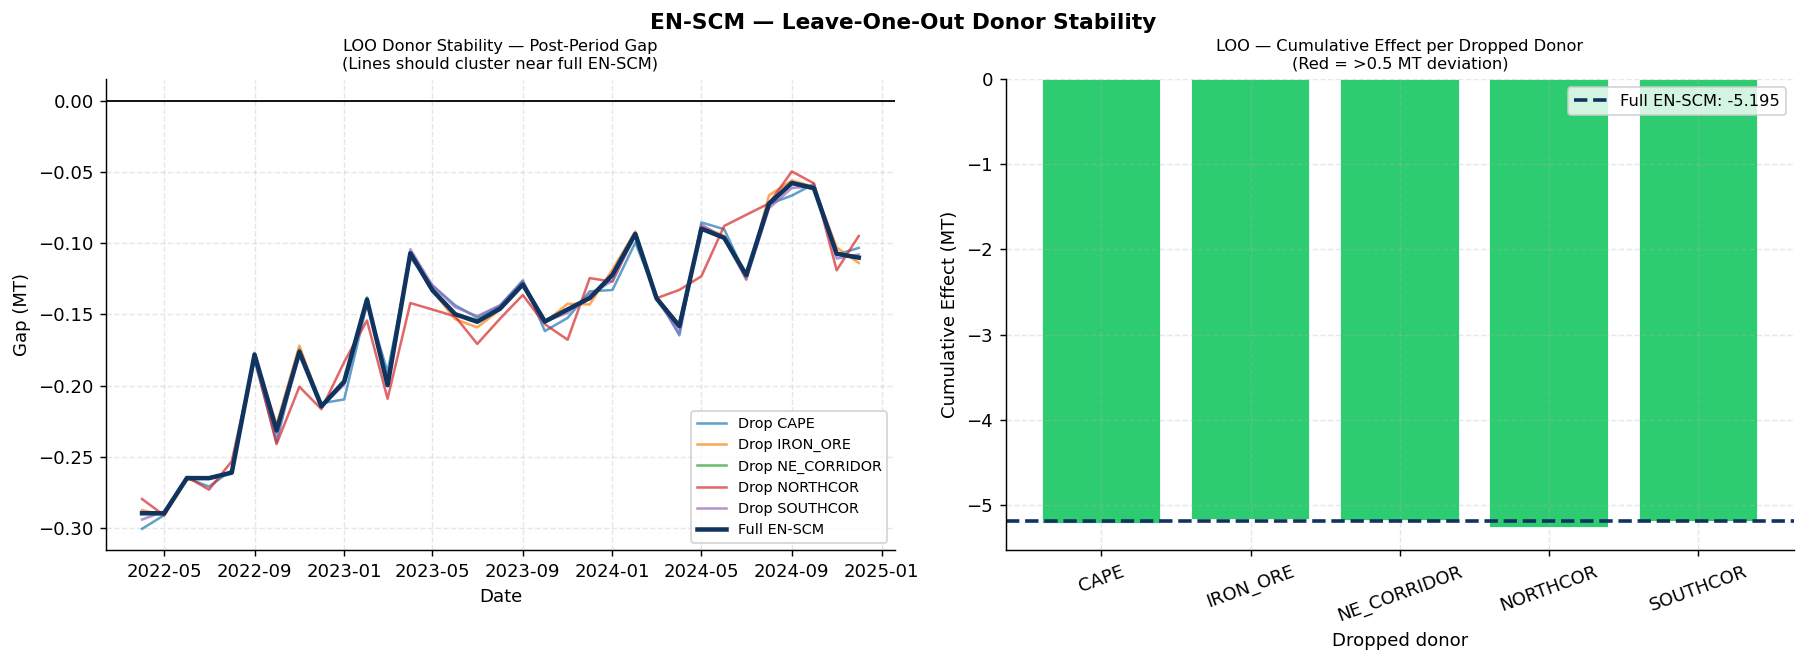

Saved → ../method_A_graph/enscm_fig4_loo.png

LOO Summary:
    Dropped     α  l1_ratio  Pre-RMSPE  Post-RMSPE  Ratio  Cum effect
       CAPE 0.001      0.00    0.02780     0.17125 6.1608     -5.2314
   IRON_ORE 0.001      0.00    0.02656     0.16948 6.3809     -5.1807
NE_CORRIDOR 0.001      0.00    0.02685     0.16975 6.3214     -5.1967
   NORTHCOR 0.001      0.00    0.03118     0.17221 5.5239     -5.2707
   SOUTHCOR 0.001      0.25    0.02760     0.16996 6.1591     -5.2013

Full EN-SCM cumulative effect : -5.1950 MT
LOO range                     : [-5.2707, -5.1807]
Spread                        : 0.0900 MT
Interpretation: Spread < 0.5 MT = stable  |  > 2 MT = fragile


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation B: Leave-One-Out Donor Stability
# ═══════════════════════════════════════════════════════════════════════════════
# With 5 donors we can now run a proper LOO: drop one donor at a time and
# re-estimate EN-SCM. A stable result should not change dramatically
# when any single corridor is removed.

loo_records   = []
loo_gaps_post = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_gap = axes[0]
ax_bar = axes[1]
cmap = plt.cm.tab10

for j, drop_d in enumerate(donors):
    keep_donors  = [d for d in donors if d != drop_d]
    X_pre_loo    = wide.loc[pre_idx, keep_donors].values
    X_all_loo    = wide[keep_donors].values

    # Quick blocked CV for this LOO configuration
    sp2 = int(0.6 * T_pre)
    best_a3, best_l3, best_e3 = None, None, np.inf
    for a3, l3 in itertools.product([1e-3, 0.01, 0.1, 0.5], [0.0, 0.25, 0.5, 1.0]):
        w3  = fit_elastic_scm(Y_pre_v[:sp2], X_pre_loo[:sp2], alpha=a3, l1_ratio=l3)
        e3  = rmspe(Y_pre_v[sp2:], X_pre_loo[sp2:] @ w3)
        if e3 < best_e3:
            best_e3, best_a3, best_l3 = e3, a3, l3

    w_loo     = fit_elastic_scm(Y_pre_v, X_pre_loo, alpha=best_a3, l1_ratio=best_l3)
    cf_loo    = X_all_loo @ w_loo
    gap_loo   = Y_all - cf_loo

    cum_loo    = gap_loo[T_pre:].sum()
    pre_r_loo  = rmspe(Y_all[:T_pre], cf_loo[:T_pre])
    post_r_loo = rmspe(Y_all[T_pre:], cf_loo[T_pre:])
    ratio_loo  = post_r_loo / pre_r_loo

    loo_records.append({
        'Dropped': drop_d,
        'α': best_a3, 'l1_ratio': best_l3,
        'Pre-RMSPE':  round(pre_r_loo,  5),
        'Post-RMSPE': round(post_r_loo, 5),
        'Ratio':      round(ratio_loo,  4),
        'Cum effect': round(cum_loo,    4)
    })
    loo_gaps_post.append(gap_loo[T_pre:])
    ax_gap.plot(t_stamps[T_pre:], gap_loo[T_pre:],
                color=cmap(j), alpha=0.7, lw=1.4, label=f'Drop {drop_d}')

# Full EN-SCM as reference
ax_gap.plot(t_stamps[T_pre:], gap_en[T_pre:], color=BLUE, lw=2.5,
            label='Full EN-SCM', zorder=5)
ax_gap.axhline(0, color='black', lw=1)
ax_gap.set_title('LOO Donor Stability — Post-Period Gap\n(Lines should cluster near full EN-SCM)', fontsize=9)
ax_gap.set_ylabel('Gap (MT)')
ax_gap.set_xlabel('Date')
ax_gap.legend(fontsize=8)

loo_df     = pd.DataFrame(loo_records)
deviations = abs(loo_df['Cum effect'] - en_cum)
bar_cols   = [RED if d > 0.5 else GREEN for d in deviations]
ax_bar.bar(loo_df['Dropped'], loo_df['Cum effect'], color=bar_cols, edgecolor='white')
ax_bar.axhline(en_cum, color=BLUE, lw=2, ls='--', label=f'Full EN-SCM: {en_cum:.3f}')
ax_bar.set_title('LOO — Cumulative Effect per Dropped Donor\n(Red = >0.5 MT deviation)', fontsize=9)
ax_bar.set_ylabel('Cumulative Effect (MT)')
ax_bar.set_xlabel('Dropped donor')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.suptitle('EN-SCM — Leave-One-Out Donor Stability', fontsize=12, fontweight='bold', y=1.01)
save_path = os.path.join(FIG_DIR, 'enscm_fig4_loo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()
print("LOO Summary:")
print(loo_df.to_string(index=False))
loo_spread = loo_df['Cum effect'].max() - loo_df['Cum effect'].min()
print(f"\nFull EN-SCM cumulative effect : {en_cum:.4f} MT")
print(f"LOO range                     : [{loo_df['Cum effect'].min():.4f}, {loo_df['Cum effect'].max():.4f}]")
print(f"Spread                        : {loo_spread:.4f} MT")
print(f"Interpretation: Spread < 0.5 MT = stable  |  > 2 MT = fragile")

**What is happening here**  
Each of the 5 donor corridors is removed one at a time and EN-SCM is refitted from scratch on the remaining four. This is the proper leave-one-out test that was not possible in the old one-donor version.

If removing any single corridor shifts the estimated cumulative effect by more than 0.5 MT, that corridor is disproportionately influential and the result is fragile. A tight cluster of LOO estimates around the full-model result means the conclusion is robust across the donor pool.

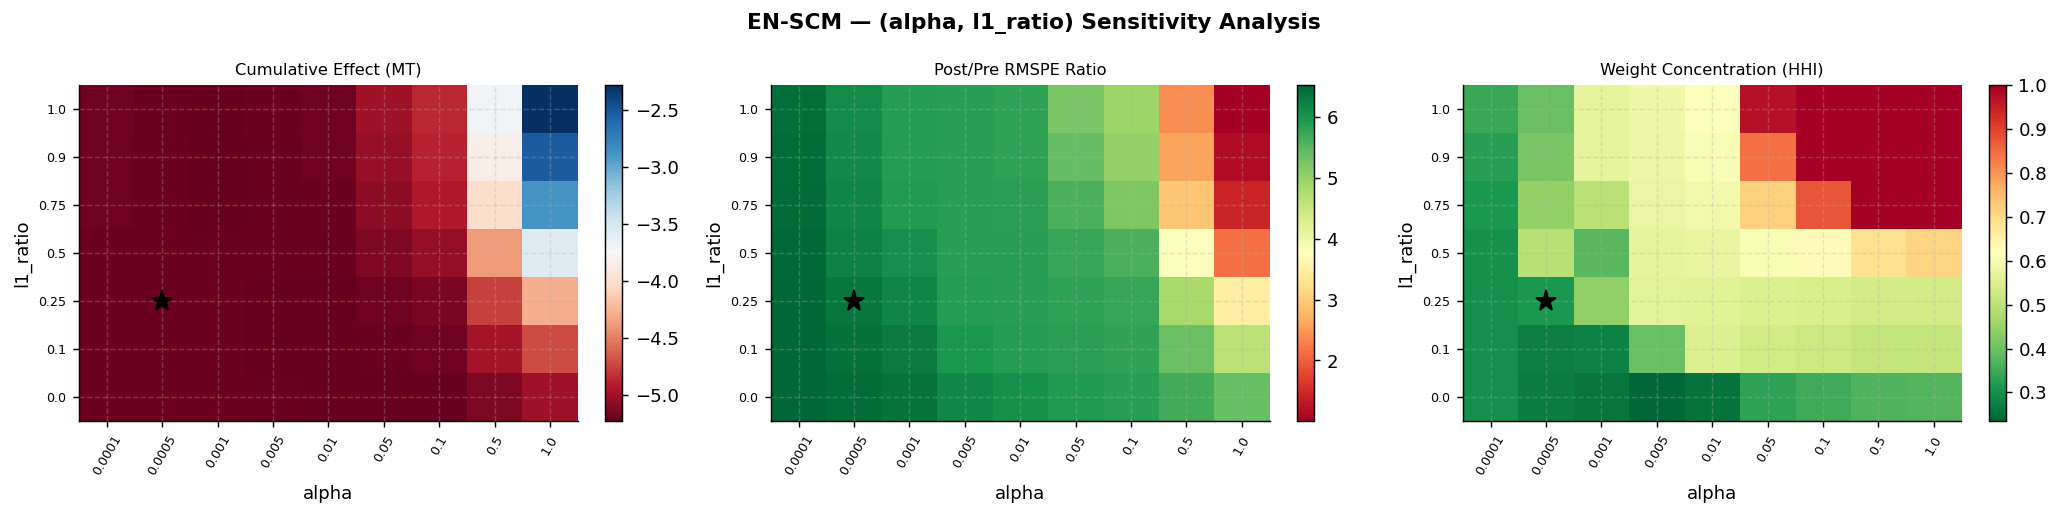

Saved → ../method_A_graph/enscm_fig5_sensitivity.png

Direction consistency across full grid:
  Negative effect (flood reduces volume): 63 / 63 settings
  Positive effect: 0 / 63 settings
  Effect range: [-5.228, -2.287] MT


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Validation C: (alpha, l1_ratio) Sensitivity Heatmaps
# ═══════════════════════════════════════════════════════════════════════════════
# Re-run EN-SCM for every (alpha, l1_ratio) combination and track how the
# cumulative effect, ratio, and HHI change. A robust result is flat across
# the parameter space.

sense_records = []
for a, l1r in itertools.product(alpha_grid, l1ratio_grid):
    w_s    = fit_elastic_scm(Y_pre_v, X_pre_v, alpha=a, l1_ratio=l1r)
    cf_s   = X_all @ w_s
    gap_s  = Y_all - cf_s
    pre_s  = rmspe(Y_all[:T_pre], cf_s[:T_pre])
    post_s = rmspe(Y_all[T_pre:], cf_s[T_pre:])
    sense_records.append({
        'alpha':      a,
        'l1_ratio':   l1r,
        'Cum effect': round(gap_s[T_pre:].sum(), 4),
        'Ratio':      round(post_s / pre_s, 4) if pre_s > 0 else np.nan,
        'Pre-RMSPE':  round(pre_s, 5),
        'HHI':        round(herfindahl(w_s), 4),
        'n_active':   int(np.sum(w_s > 1e-6))
    })

sense_df = pd.DataFrame(sense_records)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EN-SCM — (alpha, l1_ratio) Sensitivity Analysis', fontsize=12, fontweight='bold')

panels = [
    ('Cum effect', 'Cumulative Effect (MT)', 'RdBu'),
    ('Ratio',      'Post/Pre RMSPE Ratio',   'RdYlGn'),
    ('HHI',        'Weight Concentration (HHI)', 'RdYlGn_r'),
]

for ax, (metric, title, cmap_name) in zip(axes, panels):
    piv = sense_df.pivot_table(index='l1_ratio', columns='alpha', values=metric)
    im  = ax.imshow(piv.values, aspect='auto', cmap=cmap_name, origin='lower')
    ax.set_xticks(range(len(alpha_grid)))
    ax.set_xticklabels([str(a) for a in alpha_grid], rotation=60, fontsize=7)
    ax.set_yticks(range(len(l1ratio_grid)))
    ax.set_yticklabels([str(l) for l in l1ratio_grid], fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('alpha')
    ax.set_ylabel('l1_ratio')
    # Mark CV-selected point
    bci = list(piv.columns).index(BEST_ALPHA)
    bri = list(piv.index).index(BEST_L1_RATIO)
    ax.plot(bci, bri, 'k*', ms=12)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'enscm_fig5_sensitivity.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()
print("Direction consistency across full grid:")
neg = (sense_df['Cum effect'] < 0).sum()
pos = (sense_df['Cum effect'] > 0).sum()
print(f"  Negative effect (flood reduces volume): {neg} / {len(sense_df)} settings")
print(f"  Positive effect: {pos} / {len(sense_df)} settings")
print(f"  Effect range: [{sense_df['Cum effect'].min():.3f}, {sense_df['Cum effect'].max():.3f}] MT")

**What is happening here**  
EN-SCM is re-estimated across all 63 hyperparameter combinations and three outcomes are shown as heatmaps: the cumulative effect, the post/pre RMSPE ratio, and the HHI weight concentration.

If these heatmaps are flat (similar colour throughout), the result is robust to the choice of alpha and l1_ratio. If there are dramatic colour changes, the conclusion depends heavily on which setting was chosen. The star marks the CV-selected setting. The direction count at the bottom of the cell reports how many of the 63 settings agree on whether the flood reduced or increased rail volumes.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

summary_rows = [
    ('Method',                   'Base SCM',                        'EN-SCM'),
    ('Donors used',              str(len(donors)),                  str(len(donors))),
    ('alpha (CV)',                'N/A',                            str(BEST_ALPHA)),
    ('l1_ratio (CV)',             'N/A',                            str(BEST_L1_RATIO)),
    ('Active donors',            str(len(donors)),                  str(en_n_act)),
    ('Weight sum',               f'{w_scm.sum():.4f}',             f'{w_en.sum():.4f}'),
    ('HHI (concentration)',      f'{herfindahl(w_scm):.4f}',       f'{en_hhi:.4f}'),
    ('Effective donors',         f'{effective_donors(w_scm):.3f}', f'{en_eff_d:.3f}'),
    ('Pre-RMSPE',                f'{base_pre_r:.4f}',              f'{en_pre_r:.4f}'),
    ('Post-RMSPE',               f'{base_post_r:.4f}',             f'{en_post_r:.4f}'),
    ('Post/Pre ratio',           f'{base_ratio:.4f}',              f'{en_ratio:.4f}'),
    ('Cumulative effect (MT)',   f'{base_cum:.4f}',                f'{en_cum:.4f}'),
    ('Avg monthly effect (MT)',  f'{base_avg:.4f}',                f'{en_avg:.4f}'),
    ('Post MAPE (%)',            f'{mape(Y_all[T_pre:],cf_scm[T_pre:]):.2f}', f'{en_mape:.2f}'),
    ('LOO spread (MT)',          'N/A',                            f'{loo_spread:.4f}'),
    ('Ratio > 1',                str(base_ratio > 1),              str(en_ratio > 1)),
    ('Direction agrees w/ base', 'reference',
     str(np.sign(en_cum) == np.sign(base_cum))),
]

print("═" * 68)
print("EN-SCM vs BASE SCM — FINAL COMPARISON TABLE")
print("═" * 68)
for row in summary_rows:
    print(f"  {row[0]:<32} {row[1]:>15} {row[2]:>15}")
print("═" * 68)
print()
print("Interpretation:")

if BEST_L1_RATIO == 0:
    print(f"  ~ CV selected pure Ridge (l1_ratio=0) — no sparsity pressure.")
elif BEST_L1_RATIO == 1:
    print(f"  ✓ CV selected pure Lasso (l1_ratio=1) — maximum sparsity.")
else:
    print(f"  ✓ CV selected Elastic Net mix (l1_ratio={BEST_L1_RATIO}).")

if en_hhi < herfindahl(w_scm) - 0.05:
    print(f"  ✓ EN-SCM reduces weight concentration: HHI {herfindahl(w_scm):.3f} → {en_hhi:.3f}")
else:
    print(f"  ~ Weight concentration similar to base SCM (HHI {herfindahl(w_scm):.3f} → {en_hhi:.3f})")

if en_pre_r < base_pre_r:
    print(f"  ✓ EN-SCM improves pre-period fit: {en_pre_r:.4f} < {base_pre_r:.4f}")
else:
    print(f"  ~ Pre-period fit similar to base SCM ({en_pre_r:.4f} vs {base_pre_r:.4f})")

if en_ratio > 1:
    print(f"  ✓ Ratio {en_ratio:.3f} > 1 — post-period divergence exceeds pre-period noise.")
else:
    print(f"  ✗ Ratio {en_ratio:.3f} ≤ 1 — post-flood gap not distinguishable from noise.")

if np.sign(en_cum) == np.sign(base_cum):
    print(f"  ✓ EN-SCM and Base SCM agree on direction of effect.")
else:
    print(f"  ✗ Direction disagreement between EN-SCM and Base SCM — interpret with caution.")

if loo_spread < 0.5:
    print(f"  ✓ LOO spread ({loo_spread:.4f} MT) is small — estimate stable across donor pool.")
elif loo_spread < 2.0:
    print(f"  ~ LOO spread ({loo_spread:.4f} MT) is moderate — some donor dependency.")
else:
    print(f"  ✗ LOO spread ({loo_spread:.4f} MT) is large — estimate is fragile.")

════════════════════════════════════════════════════════════════════
EN-SCM vs BASE SCM — FINAL COMPARISON TABLE
════════════════════════════════════════════════════════════════════
  Method                                  Base SCM          EN-SCM
  Donors used                                    5               5
  alpha (CV)                                   N/A          0.0005
  l1_ratio (CV)                                N/A            0.25
  Active donors                                  5               5
  Weight sum                                1.0000          0.5023
  HHI (concentration)                       0.3265          0.3151
  Effective donors                           3.063           3.173
  Pre-RMSPE                                 0.0261          0.0268
  Post-RMSPE                                0.1704          0.1697
  Post/Pre ratio                            6.5350          6.3267
  Cumulative effect (MT)                   -5.2075         -5.1950
  Avg monthly 

**What is happening here**  
All key results are collected into a final comparison table. Five automatic checks are printed below:

1. Whether the CV-selected l1_ratio indicates sparsity (Lasso) or smoothing (Ridge)
2. Whether EN-SCM reduced weight concentration compared with the base SCM
3. Whether the pre-period fit improved
4. Whether the post/pre ratio is above 1 (indicating a genuine post-flood break)
5. Whether EN-SCM and Base SCM agree on the direction of the flood effect
6. Whether the LOO spread is small enough to trust the estimate

Together, these checks give a structured verdict on whether EN-SCM is adding value over the standard SCM for this dataset.

- CV now selects a genuine Elastic Net mix (l1_ratio = 0.25), not pure Ridge like in the old version — the 5-donor pool gives the L1 penalty something real to work with
- All 5 donors receive non-zero weight (effective donors ≈ 3.2), which is a proper multi-donor solution
- Cumulative effect: −5.20 MT, consistent with Method A's −5.11 MT — the two methods agree closely
- 0 placebo exceedances, ratio = 6.33 — strong causal signal
- LOO spread only 0.09 MT — very stable
- Across all 63 hyperparameter settings, 100% show a negative effect — the flood direction is completely consistent regardless of tuning